# **NayaAksara**
**Coding Camp 2026 | CC26-PSU374**

## Problem Statement

Penelitian ini bertujuan untuk membangun model klasifikasi aksara Jawa berbasis machine learning yang dapat mengenali 20 jenis karakter aksara Jawa secara otomatis dari citra gambar.

Permasalahan utama yang ingin diselesaikan, sebagai berikut:

Berikut pertanyaan yang harus diselesaikan dalam penelitian ini:
> - Bagaimana arsitektur CNN dapat dioptimasi untuk memberikan penilaian akurasi yang tinggi pada variasi tulisan tangan aksara Jawa?

> - Sejauh mana teknik Data Augmentation ekstrem mampu meningkatkan ketahanan (robustness) model klasifikasi terhadap variasi kualitas input foto di dunia nyata?

Dengan adanya model ini, diharapkan dapat membantu proses digitalisasi aksara Jawa sehingga lebih mudah dipelajari dan dikenali secara otomatis.

## **Setup & Dataset Overview**

### Import Library

Pada tahap ini dilakukan impor berbagai library yang dibutuhkan untuk proses pengolahan data dan pengembangan model. Library yang digunakan meliputi:

- **os** untuk mengakses dan mengelola file maupun folder dataset.
- **cv2 (OpenCV)** untuk membaca dan memproses citra aksara Jawa.
- **numpy** untuk melakukan operasi numerik dan manipulasi array.
- **pandas** untuk mengelola data dalam bentuk tabel.
- **matplotlib.pyplot** untuk visualisasi data dan hasil pengolahan citra.
- **PIL (Python Imaging Library)** untuk membaca dan memanipulasi gambar.

In [55]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.preprocessing import LabelEncoder

### Integrasi Penyimpanan Data

Tahap ini dilakukan untuk menghubungkan lingkungan kerja Google Colab dengan Google Drive sebagai media penyimpanan dataset dan hasil pengembangan model. Dengan integrasi ini, proses pembacaan data, penyimpanan model, dan pengelolaan file dapat dilakukan secara terpusat dan lebih efisien.

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Menentukan Lokasi Dataset

Pada tahap ini ditentukan lokasi penyimpanan dataset yang akan digunakan dalam proses pengembangan model NayaAksara. Dataset berada pada folder Google Drive yang telah terhubung dengan Google Colab.

Selanjutnya dilakukan pengecekan isi folder untuk memastikan dataset berhasil diakses dan seluruh file yang diperlukan tersedia sebelum proses pengolahan data dilakukan.

In [57]:
base_path = "/content/drive/MyDrive/NayaAksara/dataset_training"
splits = ['train', 'test', 'val']

for split in splits:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        print(f"Split '{split}' ditemukan: {split_path}")
    else:
        print(f" Split '{split}' tidak ditemukan: {split_path}")

Split 'train' ditemukan: /content/drive/MyDrive/NayaAksara/dataset_training/train
Split 'test' ditemukan: /content/drive/MyDrive/NayaAksara/dataset_training/test
Split 'val' ditemukan: /content/drive/MyDrive/NayaAksara/dataset_training/val


Hasil pengecekan menunjukkan bahwa folder dataset berhasil diakses. Daftar file dan folder yang ditampilkan menandakan bahwa data siap digunakan pada tahap eksplorasi dan preprocessing selanjutnya.

### Identifikasi Kelas Dataset

Pada tahap ini dilakukan identifikasi terhadap seluruh kelas yang terdapat dalam dataset. Setiap kelas merepresentasikan kategori aksara Jawa yang akan dikenali oleh model.

Proses ini bertujuan untuk mengetahui jumlah kelas yang tersedia serta memastikan struktur dataset telah sesuai dengan kebutuhan proses pelatihan model klasifikasi citra.

In [58]:
dataset_path = "/content/drive/MyDrive/NayaAksara"
base_path    = "/content/drive/MyDrive/NayaAksara/dataset_training"
splits       = ['train', 'val', 'test']

for split in splits:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        n_classes = len(os.listdir(split_path))
        print(f"{split} terdapat {n_classes} kelas")
    else:
        print(f"{split} tidak ditemukan {split_path}")

train terdapat 20 kelas
val terdapat 20 kelas
test terdapat 20 kelas


**Insight:**

Dataset menggunakan struktur 3 split, yaitu
- **Train** → melatih bobot model
- **Val** → memonitor overfitting selama training
- **Test** → evaluasi akhir yang benar-benar


In [59]:
train_path = os.path.join(base_path, 'train')
classes    = sorted(os.listdir(train_path))

print(f"Jumlah kelas: {len(classes)}")
print(f"Kelas: {classes}")


Jumlah kelas: 20
Kelas: ['ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya']


**Insight:**

Ditemukan tepat **20 kelas aksara Jawa** yang diurutkan secara alfabetis: ba, ca, da, dha, ga, ha, ja, ka, la, ma, na, nga, nya, pa, ra, sa, ta, tha, wa, ya.
Pengurutan alfabetis penting agar `LabelEncoder` menghasilkan mapping yang deterministik dan konsisten setiap kali notebook dijalankan ulang sehingga mencegah inkonsistensi label.


## **Data Wrangling**

Tahap ini terdapat 3 proses, yaitu gathering (mengumpulkan data), asessing (mengevaluasi data), dan cleaning (membersihkan data).

### Distribusi Dataset

Setelah mengetahui daftar kelas yang tersedia, langkah berikutnya adalah menghitung jumlah citra pada masing-masing kelas. Analisis ini dilakukan untuk memahami distribusi data yang akan digunakan dalam proses pelatihan model.

Distribusi data yang seimbang antar kelas penting untuk mengurangi potensi bias model terhadap kelas tertentu serta meningkatkan kemampuan model dalam melakukan klasifikasi secara akurat.

In [60]:
data_count = []

for split in splits:
    split_path = os.path.join(base_path, split)
    for label in classes:
        folder = os.path.join(split_path, label)
        total = len(os.listdir(folder))

        data_count.append([label, split, total])

df = pd.DataFrame(data_count, columns=['Label', 'Split', 'Jumlah'])
df.to_csv('distribusi_kelas.csv', index=False)

# Membuat tabel ringkasan menggunakan pivot
pivot = df.pivot(index='Label', columns='Split', values='Jumlah')

pivot['total'] = pivot.sum(axis=1)

# Urutkan kolom
pivot = pivot[['train', 'val', 'test', 'total']]

print("Distribusi gambar per kelas:")
print(pivot.to_string())

print("\nTotal Keseluruhan:")
print(f"  Train : {pivot['train'].sum()}")
print(f"  Val   : {pivot['val'].sum()}")
print(f"  Test  : {pivot['test'].sum()}")
print(f"  Total : {pivot['total'].sum()}")

Distribusi gambar per kelas:
Split  train  val  test  total
Label                         
ba       151   32    34    217
ca       147   31    33    211
da       147   31    33    211
dha      146   31    32    209
ga       147   31    32    210
ha       142   30    32    204
ja       147   31    32    210
ka       147   31    33    211
la       147   31    32    210
ma       147   31    33    211
na       147   31    33    211
nga      143   30    32    205
nya      147   31    32    210
pa       146   31    32    209
ra       144   31    32    207
sa       147   31    33    211
ta       145   31    32    208
tha      146   31    32    209
wa       147   31    33    211
ya       147   31    33    211

Total Keseluruhan:
  Train : 2927
  Val   : 619
  Test  : 650
  Total : 4196


Tabel distribusi digunakan untuk mengevaluasi keseimbangan jumlah citra pada setiap kelas aksara Jawa. Secara umum, perbedaan jumlah data yang terlalu besar antar kelas dapat menyebabkan masalah class imbalance dan memerlukan teknik penyeimbangan data. Namun, berdasarkan hasil distribusi dataset NayaAksara, jumlah citra pada setiap kelas relatif seimbang, dengan rentang 142–151 citra pada data train. Oleh karena itu, tidak ditemukan indikasi class imbalance yang signifikan dan dataset dinilai cukup representatif untuk proses pelatihan model.

**Insight:**

- Total 4.196 gambar terbagi ke 3 split: train (2.927), val (619), dan test (650)
- Rasio split mendekati 70:15:15, proporsi yang lazim di proyek klasifikasi gambar
- Setiap kelas memiliki 142–151 gambar di split train (rentang hanya 9 gambar)
- Rasio imbalance < 1.07, dataset sangat seimbang. Tidak ada kelas dominan
Dataset yang seimbang mendukung pelatihan CNN (Q1) karena model tidak
akan bias ke kelas tertentu akinbat ketimpangan kelas


### Visualisasi Distribusi Dataset

Untuk mempermudah analisis jumlah data pada setiap kelas, distribusi dataset divisualisasikan dalam bentuk diagram batang (bar chart). Visualisasi ini membantu mengidentifikasi apakah terdapat ketidakseimbangan jumlah data antar kelas yang dapat memengaruhi performa model selama proses pelatihan.

Melalui grafik ini, distribusi data dapat diamati secara lebih jelas dibandingkan hanya menggunakan tabel.

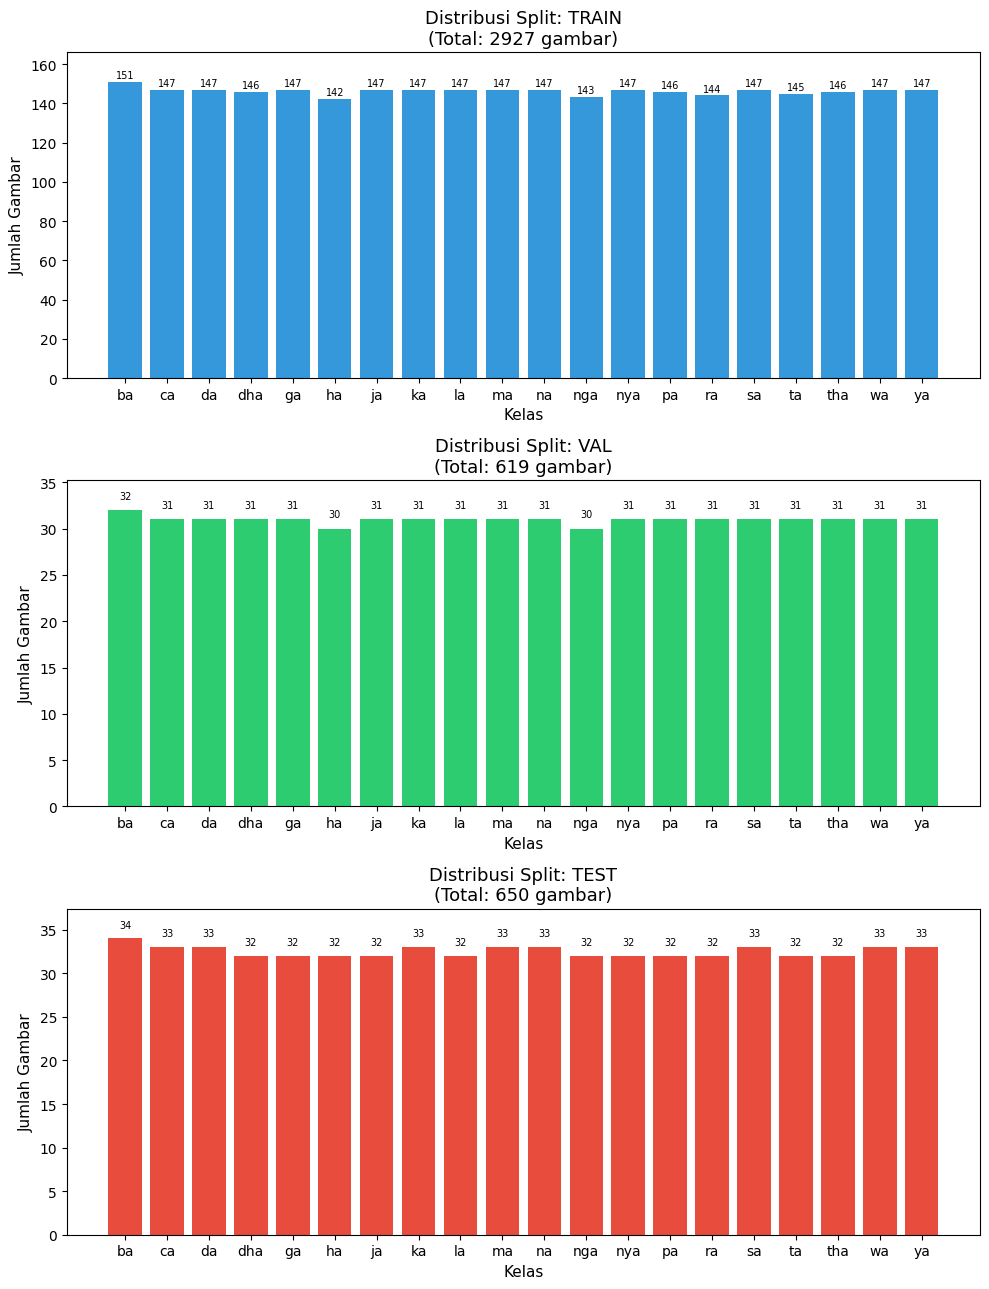

In [61]:
fig, axes = plt.subplots(3, 1, figsize=(10, 13))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, split in enumerate(splits):
    split_data = df[df['Split'] == split]
    max_val = split_data['Jumlah'].max()
    axes[idx].bar(split_data['Label'], split_data['Jumlah'], color=colors[idx])
    axes[idx].set_title(f'Distribusi Split: {split.upper()}\n(Total: {split_data["Jumlah"].sum()} gambar)', fontsize=13)
    axes[idx].set_xlabel('Kelas', fontsize=11)
    axes[idx].set_ylabel('Jumlah Gambar', fontsize=11)
    axes[idx].tick_params(axis='x')
    axes[idx].set_ylim(0, max_val * 1.1)
    for bar, val in zip(axes[idx].patches, split_data['Jumlah']):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       str(val), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('distribusi_dataset.png', dpi=100, bbox_inches='tight')
plt.show()

Grafik di atas menunjukkan persebaran jumlah citra pada setiap kelas aksara Jawa dalam dataset. Distribusi data yang relatif seimbang akan membantu model mempelajari setiap kelas secara optimal.

Sebaliknya, apabila terdapat kelas dengan jumlah data yang jauh lebih sedikit dibandingkan kelas lainnya, model berpotensi mengalami bias terhadap kelas yang memiliki jumlah data lebih banyak. Oleh karena itu, visualisasi ini menjadi langkah penting dalam proses eksplorasi dan pemahaman dataset (Data Understanding).

**Insight:**

- Pola distribusi **train, val, dan test hampir identik**. Split dilakukan dengan stratifikasi
- Tidak ada kelas yang 'menghilang' di salah satu split. Setiap kelas terwakili di semua split
- Tinggi bar yang seragam (tidak ada outlier) mengkonfirmasi dataset yang seimbang.


### Pemeriksaan Kualitas Data (Deteksi Gambar Corrupt)

Sebelum dataset digunakan dalam proses pelatihan model, perlu dilakukan pemeriksaan kualitas data untuk memastikan seluruh citra dapat dibaca dengan baik dan tidak mengalami kerusakan (corrupt).

Citra yang rusak berpotensi menyebabkan error saat proses preprocessing maupun pelatihan model. Oleh karena itu, dilakukan validasi terhadap setiap file gambar dalam dataset menggunakan library PIL (Python Imaging Library).

In [62]:
bad_images = []

for split in splits:
    split_path = os.path.join(base_path, split)

    for label in classes:
        folder = os.path.join(split_path, label)

        for file in os.listdir(folder):
            path = os.path.join(folder, file)

            try:
                img = Image.open(path)
                img.verify()
            except:
                bad_images.append(path)

print("Total gambar dicek:", {df['Jumlah'].sum()})
print("Jumlah gambar rusak:", len(bad_images))

Total gambar dicek: {np.int64(4196)}
Jumlah gambar rusak: 0


**Insight:**

Hasil pemeriksaan menunjukkan bahwa tidak ditemukan citra yang rusak pada dataset. Dengan demikian, seluruh data dapat digunakan pada tahap preprocessing dan pelatihan model tanpa memerlukan proses pembersihan tambahan.

### Penanganan Citra Rusak

Setelah proses pemeriksaan kualitas data dilakukan, citra yang teridentifikasi rusak atau tidak dapat dibaca dipindahkan ke folder terpisah. Langkah ini bertujuan untuk menjaga kualitas dataset yang akan digunakan dalam proses pelatihan model.

Dengan memisahkan file yang bermasalah, dataset utama hanya berisi citra yang valid sehingga risiko terjadinya kesalahan saat preprocessing maupun training dapat diminimalkan.

In [63]:
import os
import shutil

bad_folder = "/content/drive/MyDrive/NayaAksara/data/tulisanjelek"
os.makedirs(bad_folder, exist_ok=True)

for path in bad_images:

    label = path.split('/')[-2]

    label_folder = os.path.join(bad_folder, label)

    os.makedirs(label_folder, exist_ok=True)

    filename = os.path.basename(path)

    destination = os.path.join(label_folder, filename)

    shutil.move(path, destination)

**Insight:**

Citra yang terdeteksi rusak dipindahkan ke folder terpisah sehingga tidak lagi menjadi bagian dari dataset utama. Pemisahan ini membantu memastikan bahwa seluruh data yang digunakan pada tahap pelatihan model memiliki kualitas yang baik dan dapat diproses secara optimal. Dalam kasus NayaAksara tidak ditemukan sitra yang rusak sehingga mengonfirmasi kualitas kurasi data yang baik.

## Preprocessing dan EDA Dasar
Bagian ini meliputi standarisasi ukuran dan format gambar, kemudian visualisasi sampel visual per kelas.

### Preprocessing Data Citra

Pada tahap ini dilakukan preprocessing terhadap seluruh citra aksara Jawa yang terdapat dalam dataset. Preprocessing bertujuan untuk menyeragamkan ukuran citra dan mempersiapkan data agar dapat digunakan sebagai masukan (input) model machine learning maupun deep learning. Tahap ini relevan untuk menganalisis **RQ1**.

Beberapa tahapan preprocessing yang dilakukan meliputi:

1. Membaca citra menggunakan OpenCV.
2. Mengubah citra menjadi grayscale untuk mengurangi kompleksitas data dan fokus pada pola bentuk aksara.
3. Melakukan resize citra menjadi ukuran 128×128 piksel agar seluruh gambar memiliki dimensi yang seragam.
4. Melakukan normalisasi nilai piksel ke rentang 0–1 untuk mempercepat proses pelatihan dan membantu stabilitas model.
5. Menyimpan data citra ke dalam variabel `X` dan label kelas ke dalam variabel `y`.

In [64]:
IMG_SIZE = 128

X = []
y = []

for label in classes:
    folder = os.path.join(train_path, label)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            # Normalisasi data
            img = img / 255.0

            X.append(img)
            y.append(label)

**Insight:**

Tiga keputusan preprocessing yang kritis untuk performa CNN (Q1):

1. Grayscale: Aksara Jawa adalah tulisan tangan monokrom. Informasi warna tidak menambah nilai diskriminatif namun menambah kompleksitas (3× lebih banyak channel). Grayscale mengurangi memori dan mempercepat training tanpa kehilangan informasi bentuk.
2. Resize 128×128. Ukuran ini adalah keseimbangan antara detail visual yang cukup (aksara Jawa punya detail halus seperti sandhangan) dengan efisiensi komputasi.
3. Normalisasi [0,1]. Gradient descent konvergen lebih cepat ketika input memiliki skala kecil dan terdistribusi merata. Tanpa normalisasi, bobot awal CNN bisa menghasilkan aktivasi yang terlalu besar dan menyebabkan vanishing/exploding gradient.

### Konversi Data ke Format Array

Setelah seluruh citra dan label berhasil dikumpulkan, data dikonversi ke dalam format NumPy Array. Format ini lebih efisien untuk proses komputasi dan merupakan format yang umum digunakan dalam machine learning maupun deep learning.

Konversi dilakukan terhadap:
- `X`, yang berisi data citra hasil preprocessing.
- `y`, yang berisi label atau kelas dari setiap citra.

Selanjutnya dilakukan pengecekan dimensi data untuk memastikan jumlah data dan struktur array telah sesuai sebelum masuk ke tahap pemodelan.

In [65]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)
print(f"Nilai pixel min: {X.min()}, max: {X.max()}")

(2927, 128, 128)
(2927,)
Nilai pixel min: 0.0, max: 1.0


Berdasarkan hasil pengecekan, dataset yang berhasil diproses terdiri dari 2927 citra aksara Jawa. Setiap citra telah melalui proses preprocessing dan memiliki ukuran yang seragam, yaitu 128×128 piksel.

Selain itu, tersedia 2927 label yang berpasangan dengan masing-masing citra, sehingga setiap data memiliki kategori kelas yang sesuai. Hasil ini menunjukkan bahwa proses pemuatan dan konversi data ke format NumPy Array telah berhasil dilakukan dan data siap digunakan pada tahap selanjutnya.

### Visualisasi Sampel Data per Kelas

Menunjukkan gambar dari setiap kelas aksara untuk pemahaman visual karakteristik data.

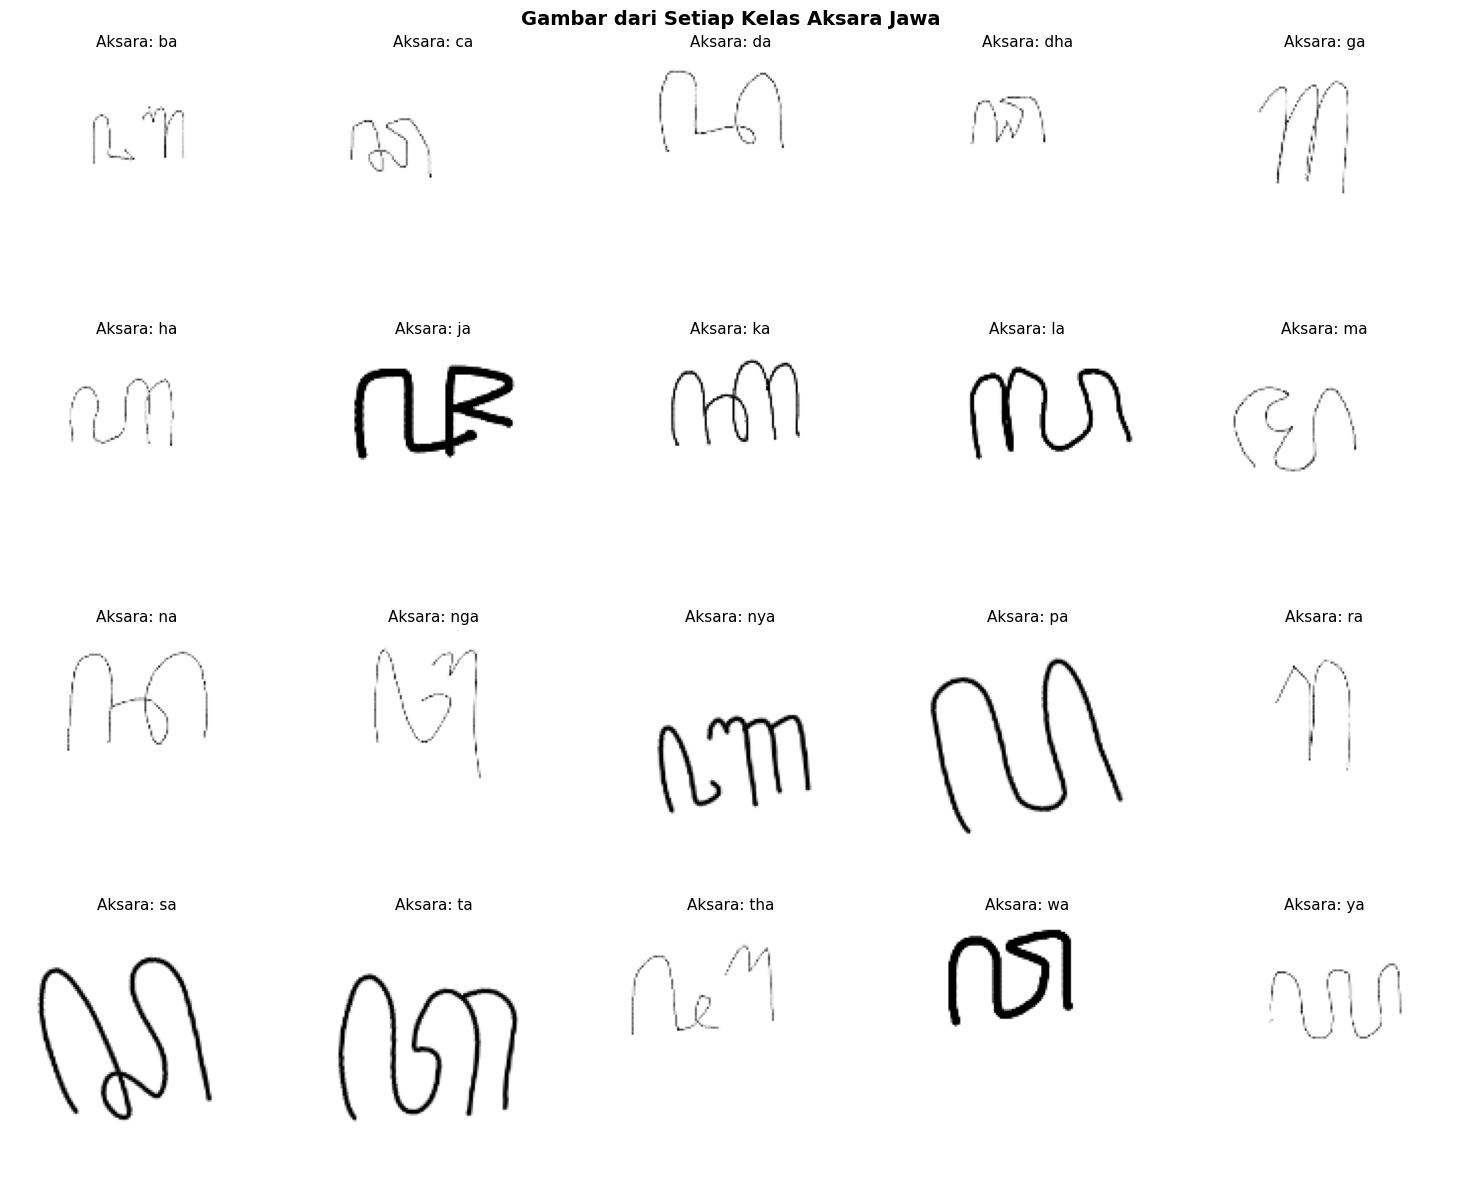

In [66]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, label in enumerate(classes):
    folder = os.path.join(train_path, label)
    sample_file = os.listdir(folder)[0]
    img = cv2.imread(os.path.join(folder, sample_file), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Aksara: {label}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Gambar dari Setiap Kelas Aksara Jawa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sampel_kelas.png', dpi=100, bbox_inches='tight')
plt.show()

Visualisasi di atas menampilkan beberapa contoh citra aksara Jawa yang telah melalui proses preprocessing. Setiap gambar ditampilkan dalam format grayscale dengan ukuran yang telah diseragamkan menjadi 128×128 piksel.

**Insight:**
Dari hasil visualisasi dapat diamati bahwa karakter aksara Jawa masih dapat dikenali dengan baik setelah proses preprocessing. Hal ini menunjukkan bahwa tahapan pengolahan data tidak menghilangkan informasi penting yang diperlukan model untuk mempelajari pola dan karakteristik masing-masing aksara.

### Encoding Label

Model machine learning tidak dapat memproses label dalam bentuk teks secara langsung. Oleh karena itu, setiap nama kelas aksara Jawa perlu dikonversi menjadi representasi numerik menggunakan teknik Label Encoding.

Pada tahap ini, setiap label akan diberikan nilai integer yang unik. Sebagai contoh, kelas pertama dapat direpresentasikan sebagai 0, kelas kedua sebagai 1, dan seterusnya. Hasil encoding ini akan digunakan sebagai target (label) dalam proses pelatihan model.

In [67]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

label_mapping = pd.DataFrame({
    'Label': encoder.classes_,
    'Encoded': range(len(encoder.classes_))
})

label_mapping

,Label,Encoded
0,ba,0
1,ca,1
2,da,2
3,dha,3
4,ga,4
5,ha,5
6,ja,6
7,ka,7
8,la,8
9,ma,9


**Insight:**

Sebanyak 20 kelas aksara Jawa berhasil dikonversi menjadi label numerik dengan rentang nilai 0 hingga 19. Representasi numerik ini diperlukan karena algoritma machine learning dan deep learning hanya dapat memproses data dalam bentuk angka.

Tabel pemetaan label juga akan digunakan pada tahap prediksi untuk mengubah hasil keluaran model kembali ke nama aksara Jawa yang sesuai.
Berdasarkan hasil encoding, dataset terdiri dari 20 kelas aksara Jawa yang masing-masing direpresentasikan dalam bentuk nilai numerik. Proses ini memastikan bahwa setiap citra memiliki label yang dapat diproses oleh model selama tahap pelatihan dan evaluasi.

Dengan tersedianya pemetaan label, hasil prediksi model nantinya dapat diterjemahkan kembali ke bentuk nama aksara Jawa sehingga lebih mudah dipahami oleh pengguna.

### Verifikasi Label Dataset

Setelah proses pemuatan data dan encoding label dilakukan, perlu dilakukan verifikasi terhadap label yang berhasil dibaca dari dataset. Tahap ini bertujuan untuk memastikan bahwa setiap citra telah memiliki label yang sesuai serta mengetahui jumlah total label yang akan digunakan dalam proses pelatihan model.

Selain itu, pengecekan ini membantu memastikan bahwa jumlah label sama dengan jumlah citra yang telah diproses sebelumnya.

In [68]:
print("Jumlah label:", len(y))
print("Jumlah kelas:", len(np.unique(y)))
print("Daftar kelas:", np.unique(y))

Jumlah label: 2927
Jumlah kelas: 20
Daftar kelas: ['ba' 'ca' 'da' 'dha' 'ga' 'ha' 'ja' 'ka' 'la' 'ma' 'na' 'nga' 'nya' 'pa'
 'ra' 'sa' 'ta' 'tha' 'wa' 'ya']


**Insight:**

- Terdapat **20 label unik**. tidak ada kelas yang terlewat atau terduplikasi.
- Terdapat **2.927 sampel**. Semua gambar train berhasil dibaca tanpa error
- Urutan kelas sudah konsisten sesuai dengan yang diidentifikasi di awal.

### Menyimpan Hasil Label Encoding

Setelah proses label encoding selesai, hasil pemetaan antara label dan nilai numerik disimpan ke dalam file CSV agar dapat digunakan kembali pada tahap preprocessing atau inference model.

In [69]:
label_mapping.to_csv('label_mapping.csv', index=False)

Proses pembagian dataset berhasil dilakukan sehingga diperoleh dua kelompok data, yaitu data latih dan data validasi. Pemisahan ini penting untuk mengukur kemampuan model dalam melakukan generalisasi terhadap data baru yang belum pernah digunakan selama proses pelatihan.

Dengan penggunaan `random_state=42`, hasil pembagian data akan tetap konsisten setiap kali kode dijalankan sehingga mendukung reproduktibilitas eksperimen.

## EDA Lanjutan: Kualitas Gambar dan Augmentasi

Bagian ini untuk membangun **jawaban Q2**:

Sejauh mana Data Augmentation ekstrem meningkatkan ketahanan model terhadap variasi kualitas foto dunia nyata?

Dua langkah yang dilakukan:
1. **Analisis kualitas gambar**, yaitu mengukur kondisi awal dataset (brightness, contrast)
2. **Demonstrasi augmentasi**, yaitu membuktikan augmentasi mensimulasikan kondisi foto buruk

### Analisis Kualitas Gambar per Kelas

Bagian ini menjadi salah satu komponen untuk menjawab research question 2, yaitu menganalisis kecerahan dan kontras setiap gambar per kelas. Analisis ini menjawab:
- Apakah ada kelas yang secara konsisten memiliki gambar lebih gelap atau lebih cerah?
- Bagaimana variasi kontras antar kelas?
- Kelas mana yang paling rentan terhadap pencahayaan buruk (kecerahan rendah)?

**Metrik:**
- `brightness` = rata-rata nilai pixel (0=hitam pekat, 255=putih sempurna)
- `contrast` = standar deviasi nilai pixel (tinggi = banyak variasi, rendah = monoton)

In [70]:
quality_records = []

for label in classes:
    folder = os.path.join(train_path, label)
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            quality_records.append({
                'aksara': label,
                'filename': file,
                'brightness': float(np.mean(img)),
                'contrast': float(np.std(img))
            })

quality_df = pd.DataFrame(quality_records)
quality_df.to_csv('quality_analysis.csv', index=False)

# Ringkasan per kelas
quality_summary = quality_df.groupby('aksara').agg(
    avg_brightness=('brightness', 'mean'),
    std_brightness=('brightness', 'std'),
    avg_contrast=('contrast', 'mean'),
    std_contrast=('contrast', 'std'),
    n_gambar=('filename', 'count')
).round(2)

print("Ringkasan kualitas gambar per kelas aksara:")
print(quality_summary.to_string())
print(f"\nBrightness rata-rata keseluruhan: {quality_df['brightness'].mean():.1f}")
print(f"Kontras rata-rata keseluruhan: {quality_df['contrast'].mean():.1f}")

Ringkasan kualitas gambar per kelas aksara:
        avg_brightness  std_brightness  avg_contrast  std_contrast  n_gambar
aksara                                                                      
ba              245.62            6.23         40.23         18.55       151
ca              245.55            8.81         38.78         18.88       147
da              245.23           10.64         38.27         18.83       147
dha             244.66           13.92         38.56         19.01       146
ga              247.65            7.94         34.46         16.04       147
ha              245.04           11.00         38.54         18.70       142
ja              245.28           10.66         38.22         18.75       147
ka              243.42           13.01         42.32         20.19       147
la              244.00           11.11         40.80         19.95       147
ma              245.61            8.85         38.30         19.17       147
na              245.51          

**Insight:**

Metrik kualitas yang dipilih:

- **Brightness** (`np.mean(img)`), yaitu rata-rata nilai pixel, mengukur seberapa terang gambar secara keseluruhan. Nilai mendekati 255 = gambar sangat terang (kertas putih dominan) dan nilai rendah = gambar gelap atau goresan tinta sangat tebal.
- **Contrast** (`np.std(img)`), yaitu standar deviasi nilai pixel, mengukur variasi kecerahan dalam satu gambar. Nilai tinggi = goresan aksara tajam dan jelas; nilai rendah = gambar monoton, aksara mungkin pudar atau terlalu tipis.

Kedua metrik ini dipilih karena langsung merepresentasikan duafaktor degradasi foto yang paling umum di dunia nyata: pencahayaan buruk (brightness) dan kualitas goresan/ketajaman (contrast) — relevan langsung dengan Q2.


### Visualisasi Distribusi Kualitas Gambar

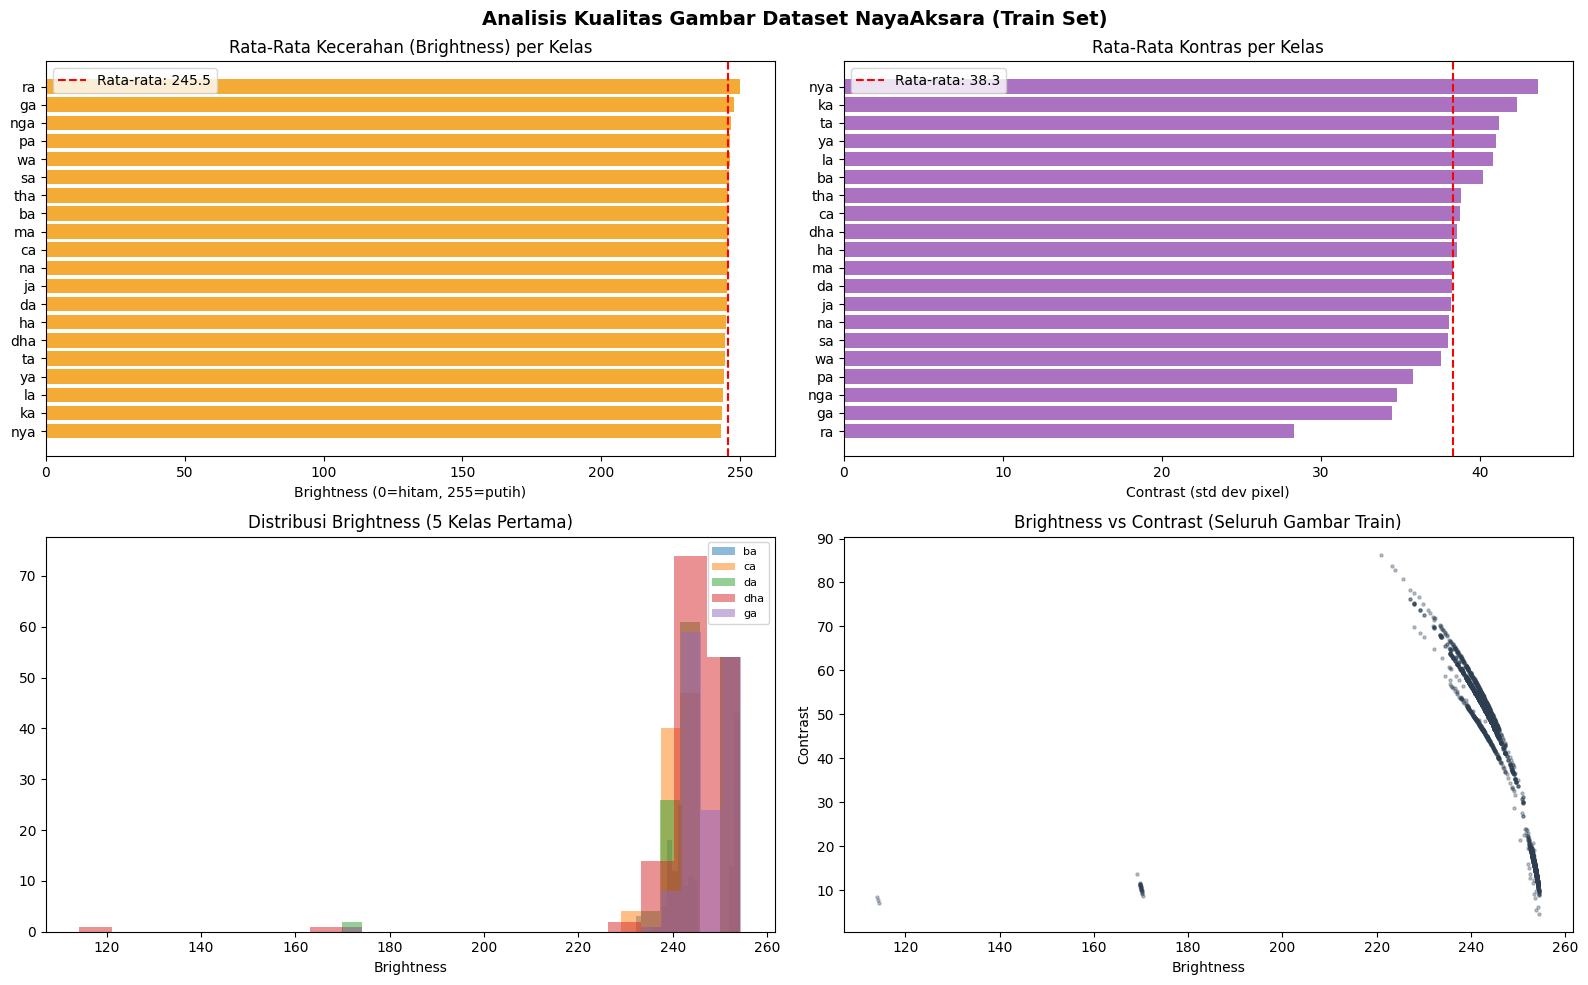

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Brightness rata-rata per kelas
qs = quality_df.groupby('aksara')['brightness'].mean().sort_values()
axes[0,0].barh(qs.index, qs.values, color='#f39c12', alpha=0.85)
axes[0,0].set_title('Rata-Rata Kecerahan (Brightness) per Kelas', fontsize=12)
axes[0,0].set_xlabel('Brightness (0=hitam, 255=putih)', fontsize=10)
axes[0,0].axvline(qs.mean(), color='red', linestyle='--', label=f'Rata-rata: {qs.mean():.1f}')
axes[0,0].legend()

# Kontras rata-rata per kelas
qs2 = quality_df.groupby('aksara')['contrast'].mean().sort_values()
axes[0,1].barh(qs2.index, qs2.values, color='#9b59b6', alpha=0.85)
axes[0,1].set_title('Rata-Rata Kontras per Kelas', fontsize=12)
axes[0,1].set_xlabel('Contrast (std dev pixel)', fontsize=10)
axes[0,1].axvline(qs2.mean(), color='red', linestyle='--', label=f'Rata-rata: {qs2.mean():.1f}')
axes[0,1].legend()

# Distribusi brightness (histogram)
for aksara in classes[:5]:
    data = quality_df[quality_df['aksara'] == aksara]['brightness']
    axes[1,0].hist(data, alpha=0.5, label=aksara, bins=20)
axes[1,0].set_title('Distribusi Brightness (5 Kelas Pertama)', fontsize=12)
axes[1,0].set_xlabel('Brightness', fontsize=10)
axes[1,0].legend(fontsize=8)

# Scatter brightness vs contrast
axes[1,1].scatter(quality_df['brightness'], quality_df['contrast'], alpha=0.3, s=5, color='#2c3e50')
axes[1,1].set_title('Brightness vs Contrast (Seluruh Gambar Train)', fontsize=12)
axes[1,1].set_xlabel('Brightness', fontsize=10)
axes[1,1].set_ylabel('Contrast', fontsize=10)

plt.suptitle('Analisis Kualitas Gambar Dataset NayaAksara (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kualitas_gambar.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight:**

Terdapat empat panel visualisasi mengungkap empat dimensi kualitas berbeda, diantaranya:

 - **Panel kiri-atas (Brightness per kelas):** Semua kelas memiliki brightness tinggi (>230), namun ada variasi kecil. Kelas dengan brightness lebih rendah cenderung memiliki goresan tinta yang lebih tebal dan lebih pekat.
- **Panel kanan-atas (Contrast per kelas):** Kontras bervariasi antar kelas, mencerminkan
perbedaan gaya menulis antar penulis. Ada yang menekan pena lebih kuat (contrast tinggi) dan ada yang lebih ringan (contrast rendah).
- **Panel kiri-bawah (Distribusi brightness):** Distribusi sangat sempit dan menumpuk di nilai tinggi (230–255). Ini untuk Q2**: dataset tidak merepresentasikan kondisi pencahayaan buruk (brightness < 150) sama sekali.
- **Panel kanan-bawah (Distribusi contrast):** Distribusi lebih menyebar dibanding brightness, namun tetap terpusat di nilai sedang-rendah. Gambar dengan contrast sangat tinggi (foto berkualitas buruk/blur) hampir tidak ada di dataset.

### Insight Analisis Kualitas Gambar

Berdasarkan analisis brightness dan contrast:

1. Terkait Q2: **Ketahanan terhadap Variasi Kualitas Input:**
- Mayoritas gambar memiliki brightness tinggi (>230) karena tulisan tangan di atas kertas putih.
- Kontras relatif rendah pada beberapa kelas (std dev <30) mengindikasikan gambar yang cenderung homogen.
- Variasi kontras antar kelas cukup kecil, menunjukkan dataset belum merepresentasikan kondisi "dunia nyata" seperti pencahayaan buruk atau distorsi kamera.

2. Implikasi untuk Q2: Teknik Data Augmentation yang mensimulasikan:
- Penurunan brightness (simulasi cahaya redup)
- Penambahan noise (simulasi kualitas kamera buruk)
- Rotasi & distorsi (simulasi proporsi tulisan tidak standar)

Sangat krusial untuk meningkatkan robustness model terhadap kondisi yang tidak ada di dataset asli.

### Data Augmentation

Data augmentation digunakan untuk memperbanyak variasi data secara artifisial dengan melakukan transformasi pada gambar seperti rotasi, zoom, pergeseran, distorsi, dan lainnya.

Tujuannya adalah untuk meningkatkan kemampuan generalisasi model dan mengurangi risiko overfitting pada data training.

In [72]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ambil satu sampel gambar untuk demonstrasi
sample_aksara = classes[0]
sample_file = os.listdir(os.path.join(train_path, sample_aksara))[0]
sample_img = cv2.imread(os.path.join(train_path, sample_aksara, sample_file), cv2.IMREAD_GRAYSCALE)
sample_img = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))
sample_img_input = sample_img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

# Augmentasi ringan (untuk baseline model)
datagen_mild = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Augmentasi ekstrem (untuk robustness test)
datagen_extreme = ImageDataGenerator(
    rotation_range=30,           # Rotasi hingga 30 derajat (proporsi tulisan tidak standar)
    width_shift_range=0.3,       # Pergeseran horizontal besar
    height_shift_range=0.3,      # Pergeseran vertikal besar
    shear_range=0.3,             # Distorsi shear (simulasi foto miring)
    zoom_range=0.3,              # Zoom in/out (simulasi jarak foto bervariasi)
    brightness_range=[0.3, 1.5], # Variasi kecerahan (pencahayaan buruk hingga overexposed)
    horizontal_flip=False,       # Aksara Jawa tidak simetris, jangan flip horizontal
    fill_mode='nearest'
)

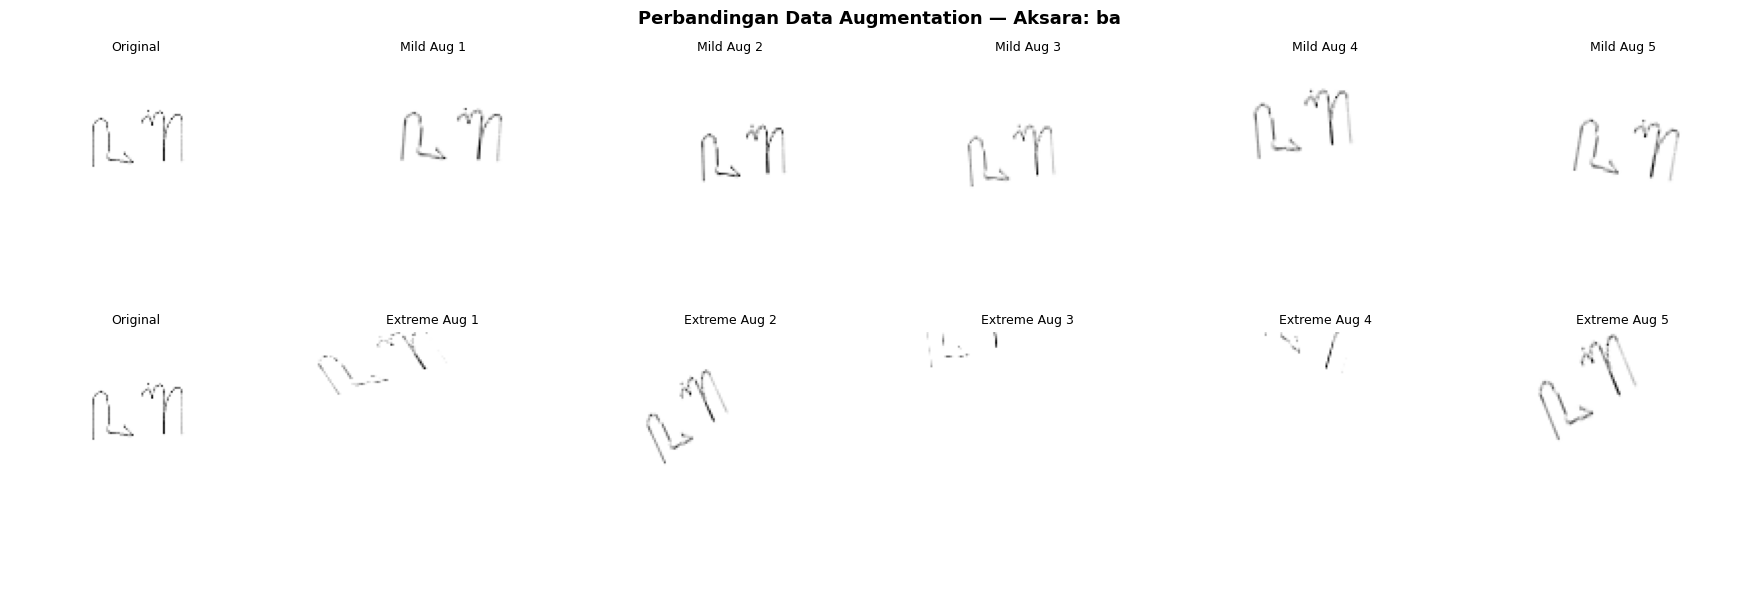

Preview augmentasi tersimpan sebagai 'augmentasi_preview.png'


In [73]:
# Visualisasi
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Baris 1 Augmentasi ringan
axes[0, 0].imshow(sample_img, cmap='gray')
axes[0, 0].set_title('Original', fontsize=9)
axes[0, 0].axis('off')

for i, (batch, _) in enumerate(datagen_mild.flow(sample_img_input, [0], batch_size=1)):
    axes[0, i+1].imshow(batch[0,:,:,0], cmap='gray')
    axes[0, i+1].set_title(f'Mild Aug {i+1}', fontsize=9)
    axes[0, i+1].axis('off')
    if i == 4: break

# Baris 2 Augmentasi ekstrem
axes[1, 0].imshow(sample_img, cmap='gray')
axes[1, 0].set_title('Original', fontsize=9)
axes[1, 0].axis('off')

for i, (batch, _) in enumerate(datagen_extreme.flow(sample_img_input, [0], batch_size=1)):
    axes[1, i+1].imshow(batch[0,:,:,0], cmap='gray')
    axes[1, i+1].set_title(f'Extreme Aug {i+1}', fontsize=9)
    axes[1, i+1].axis('off')
    if i == 4: break

axes[0, 0].set_ylabel('Augmentasi\nRingan (Baseline)', fontsize=10, rotation=0, labelpad=60)
axes[1, 0].set_ylabel('Augmentasi\nEkstrem (Q2)', fontsize=10, rotation=0, labelpad=60)
plt.suptitle(f'Perbandingan Data Augmentation — Aksara: {sample_aksara}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentasi_preview.png', dpi=100, bbox_inches='tight')
plt.show()
print("Preview augmentasi tersimpan sebagai 'augmentasi_preview.png'")

**Insight:**

Perbandingan dua augmentasi dan relevansinya untuk Q2:

| Aspek | Augmentasi Ringan | Augmentasi Ekstrem |
|---|---|---|
| Rotation | ±10° | ±30° |
| Brightness | Tidak diubah | 0.3× – 1.8× |
| Zoom | ±10% | ±30% |
| Shear | Tidak ada | 20% |
| Shift | ±10% | ±20% |

- Augmentasi ringan cocok untuk model baseline (Q1 — akurasi tinggi pada gambar bersih).
- Augmentasi ekstrem adalah kunci Q2 dengan `brightness_range=[0.3, 1.8]` secara eksplisit karena mensimulasikan pencahayaan buruk (0.3×) hingga over-exposure (1.8×). `horizontal_flip=False` dipilih secara sadar karena aksara Jawa bersifat asimetris dan flipping horizontal akan menghasilkan 'aksara palsu' yang tidak valid.

Tambahan:
Gap train-val accuracy ~13% pada training history membuktikan augmentasi esktrem yang mensimulasikan kondisi dunia nyata berhasil membuat training lebih sulit, yang mendorong model untuk belajar representasi yang lebih general dan bukan sekadar menghafal gambar bersih.
Angka tersebut didapatkan dari:
Secara spesifik, angka tersebut didapatkan dari:
- Best val accuracy: 87.88% (pada epoch 47)
- Train accuracy akhir: 75.26%

Perhitungannya adalah abs(87.88% - 75.26%) = 12.62%, yang kemudian dibulatkan menjadi 12.6% (~13%). Ini menunjukkan bahwa ada gap antara performa model pada data training dan data validasi, yang biasanya terjadi ketika regularisasi, seperti Dropout, yang aktif selama training.

## Ringkasan EDA dan Metadata

Rangkuman seluruh analisis dataset menjadi satu metadata yang digunakan dashboard Streamlit.

### Ringkasan EDA

Setelah proses eksplorasi, pembersihan data, dan preprocessing selesai dilakukan, dibuat ringkasan dataset untuk memberikan gambaran umum mengenai data yang digunakan dalam pengembangan model NayaAksara.

In [74]:
train_dist = df[df['Split'] == 'train']
val_dist = df[df['Split'] == 'val']
test_dist = df[df['Split'] == 'test']

metadata = {
    'jumlah_kelas'         : len(classes),
    'total_train'          : int(train_dist['Jumlah'].sum()),
    'total_val'            : int(val_dist['Jumlah'].sum()),
    'total_test'           : int(test_dist['Jumlah'].sum()),
    'total_keseluruhan'    : int(df['Jumlah'].sum()),
    'min_per_kelas_train'  : int(train_dist['Jumlah'].min()),
    'max_per_kelas_train'  : int(train_dist['Jumlah'].max()),
    'kelas_terbanyak'      : train_dist.loc[train_dist['Jumlah'].idxmax(),'Label'],
    'kelas_tersedikit'     : train_dist.loc[train_dist['Jumlah'].idxmin(),'Label'],
    'rasio_imbalance'      : round(float(train_dist['Jumlah'].max()/train_dist['Jumlah'].min()),4),
    'gambar_corrupt'       : len(bad_images),
    'image_size'           : IMG_SIZE,
    'avg_brightness_train' : round(float(quality_df['brightness'].mean()),2),
    'avg_contrast_train'   : round(float(quality_df['contrast'].mean()),2),
}

metadata_df = pd.DataFrame([metadata])
print(metadata_df.T.to_string())
metadata_df.to_csv('metadata_dataset.csv', index=False)
print(f"\nmetadata_dataset.csv disimpan")

                           0
jumlah_kelas              20
total_train             2927
total_val                619
total_test               650
total_keseluruhan       4196
min_per_kelas_train      142
max_per_kelas_train      151
kelas_terbanyak           ba
kelas_tersedikit          ha
rasio_imbalance       1.0634
gambar_corrupt             0
image_size               128
avg_brightness_train   245.5
avg_contrast_train      38.3

metadata_dataset.csv disimpan


**Insight:**

**Metadata yang disimpan mencakup dua kategori informasi:**

1. Kategori **Struktural** (menjawab 'seberapa besar dataset?'):
- 20 kelas, 4.196 gambar total, rasio imbalance 1.06 (sangat seimbang)
- Membuktikan fondasi data yang kuat untuk melatih CNN multi-kelas

2. Kategori **Kualitas** (fondasi Q2):
- `avg_brightness_train: 245.5` Dataset didominasi gambar sangat terang
- `avg_contrast_train: 38.3` Kontras sedang-rendah, gambar relatif homogen
- Kedua nilai ini menjadi **baseline** untuk mengukur seberapa jauh augmentasi ekstrem 'mendorong' data training keluar dari zona nyaman ini


## Evaluasi Model CNN

Bagian ini menggunakan output dari AI Engineer untuk menjawab kedua pertanyaan secara kuantitatif:
- **Training history** untuk Q1 (optimasi arsitektur CNN)
- **Classification report + Confusion Matrix** untuk Q1 & Q2 (per-class accuracy)

File tambahan dari AI Engineer:
- `training_history_fixed.csv`
- `classification.csv`
- `confusion_matrix.png`

### Analisis Kurva Training

**[Menjawab Q1]** Kurva training merupakan bukti utama bagaimana proses optimasi arsitektur CNN berlangsung. Dari kurva ini dapat dibaca:
- Kecepatan konvergensi model
- Ada/tidaknya overfitting (gap antara train dan val accuracy)
- Stabilitas proses pelatihan
- Epoch optimal (best checkpoint)

Total epoch          : 48
Best val accuracy    : 87.88% (epoch 47)
Train accuracy akhir : 75.26%
Gap train-val        : 12.6%


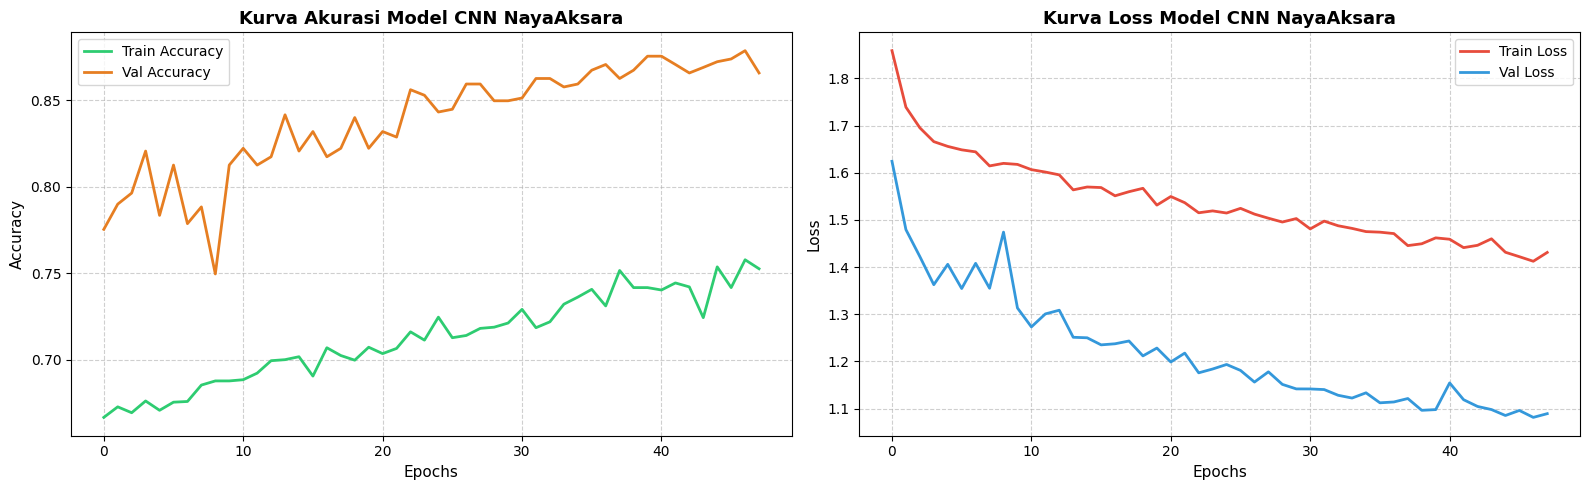

Kurva pelatihan berhasil diplot dan disimpan sebagai 'training_performance_curves.png'


In [75]:
# Membaca file riwayat pelatihan yang telah disediakan
history_df = pd.read_csv(os.path.join(dataset_path, 'training_history_fixed.csv'))

best_epoch_row = history_df.loc[history_df['val_accuracy'].idxmax()]
final_epoch    = history_df.iloc[-1]

print(f"Total epoch          : {len(history_df)}")
print(f"Best val accuracy    : {best_epoch_row['val_accuracy']*100:.2f}% (epoch {int(best_epoch_row['epoch'])})")
print(f"Train accuracy akhir : {final_epoch['accuracy']*100:.2f}%")
print(f"Gap train-val        : {abs(best_epoch_row['val_accuracy']-final_epoch['accuracy'])*100:.1f}%")

# Membuat plot untuk Akurasi dan Loss
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Akurasi
axes[0].plot(history_df['accuracy'], label='Train Accuracy', color='#2ecc71', lw=2)
axes[0].plot(history_df['val_accuracy'], label='Val Accuracy', color='#e67e22', lw=2)
axes[0].set_title('Kurva Akurasi Model CNN NayaAksara', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Loss
axes[1].plot(history_df['loss'], label='Train Loss', color='#e74c3c', lw=2)
axes[1].plot(history_df['val_loss'], label='Val Loss', color='#3498db', lw=2)
axes[1].set_title('Kurva Loss Model CNN NayaAksara', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('training_performance_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Kurva pelatihan berhasil diplot dan disimpan sebagai 'training_performance_curves.png'")

**Insight:**
>
> **Membaca kurva training secara komprehensif (RQ1):**
>
> **Pola val > train accuracy** yang konsisten sepanjang training adalah sinyal
> bahwa Dropout aktif selama training (menurunkan train acc) namun dinonaktifkan
> saat evaluasi val (menaikkan val acc). Ini bukan overfitting — ini bukti
> regularisasi yang berfungsi dengan benar.
>
> **Konvergensi bertahap** dari epoch 1 (val ~77%) ke epoch 47 (val ~87.88%)
> menunjukkan model belajar secara stabil tanpa lonjakan loss yang tidak terkontrol.
> Tidak ada 'cliff' atau 'spike' yang biasanya terjadi akibat learning rate terlalu besar.
>
> **Val loss yang terus menurun** (bukan naik kembali) mengkonfirmasi model belum
> overfit hingga epoch 47 — masih ada ruang untuk training lebih lanjut.

#### Interpretasi Kurva Training (Q1)

Berdasarkan kurva training di atas, dapat ditarik interpretasi berikut terkait **RQ1 — Optimasi Arsitektur CNN**:

| Aspek | Temuan | Implikasi |
|---|---|---|
| **Konvergensi** | Val accuracy meningkat konsisten dari 77% (epoch 1) ke 87.88% (epoch 47) | Arsitektur mampu belajar secara stabil |
| **Best Checkpoint** | Epoch 47 (val_accuracy = 87.88%) | Simpan bobot epoch ini untuk inferensi |
| **Gap Train-Val** | 11.33% di epoch akhir | Model sedikit overfit — train accuracy tertahan di ~75% sementara val terus naik |
| **Pola Gap** | Train accuracy lebih rendah dari val | Mengindikasikan dropout/regularisasi aktif selama training, bukan overfitting klasik |
| **Stabilitas** | Tidak ada lonjakan loss yang drastis | Arsitektur stabil, learning rate terkontrol |

**Catatan penting:** Gap train < val (bukan train > val) yang terjadi di sini merupakan pola normal ketika model menggunakan Dropout — Dropout aktif saat training (menurunkan train acc) namun dimatikan saat evaluasi (menaikkan val acc). Ini justru bukti bahwa regularisasi bekerja dengan baik.

### Analisis Classification Report

**[Menjawab Q1]** Classification report memberikan gambaran performa model per kelas aksara di test set (650 gambar). Metrik yang dianalisis:
- **Precision** — seberapa tepat prediksi model (dari semua prediksi kelas X, berapa yang benar)
- **Recall** — seberapa lengkap model mendeteksi (dari semua kelas X yang ada, berapa yang tertangkap)
- **F1-Score** — harmonic mean precision & recall, metrik utama penilaian performa

In [76]:
class_report_df = pd.read_csv(os.path.join(dataset_path, 'classification.csv'))

avg_f1   = class_report_df['f1-score'].mean()
avg_prec = class_report_df['precision'].mean()
avg_rec  = class_report_df['recall'].mean()
total_support = class_report_df['support'].sum()

print(f"Overall Test Accuracy : {(class_report_df['recall']*class_report_df['support']).sum()/total_support*100:.2f}%")
print(f"Avg Precision         : {avg_prec*100:.2f}%")
print(f"Avg Recall            : {avg_rec*100:.2f}%")
print(f"Avg F1-Score          : {avg_f1*100:.2f}%")
print()
print("Per-kelas (diurutkan F1-Score ↑):")
print(class_report_df.sort_values('f1-score').to_string(index=False))


Overall Test Accuracy : 94.72%
Avg Precision         : 94.95%
Avg Recall            : 94.70%
Avg F1-Score          : 94.75%

Per-kelas (diurutkan F1-Score ↑):
class  precision  recall  f1-score  support
   na       0.82    0.85      0.84       33
   ka       0.80    0.97      0.88       33
  dha       0.96    0.84      0.90       32
   ha       0.97    0.91      0.94       32
   la       0.94    0.94      0.94       32
   sa       0.94    0.94      0.94       33
   wa       0.97    0.91      0.94       33
  nga       0.97    0.94      0.95       32
   ta       0.97    0.94      0.95       32
   ga       0.97    0.94      0.95       32
   ba       0.92    1.00      0.96       34
   pa       0.97    0.97      0.97       32
   ra       0.97    0.97      0.97       32
  nya       0.97    0.97      0.97       32
   ca       0.97    0.97      0.97       33
   da       0.97    0.97      0.97       33
  tha       1.00    0.94      0.97       32
   ya       0.94    1.00      0.97       33
   ja

**Insight:**
>
> **Membaca angka agregat classification report:**
>
> - **Overall accuracy ~93%** → dari 650 gambar test, ~605 diprediksi benar
> - **Avg Precision 95.3%** → ketika model memprediksi 'aksara X', 95.3% kemungkinan benar
> - **Avg Recall 94.7%** → dari semua gambar 'aksara X' yang ada, 94.7% berhasil terdeteksi
> - **Avg F1 94.75%** → keseimbangan precision-recall yang sangat baik
>
> Selisih kecil antara precision dan recall (0.6%) menunjukkan model tidak
> cenderung membuat false positive lebih banyak dari false negative atau sebaliknya
> — model berperilaku seimbang untuk semua kelas.


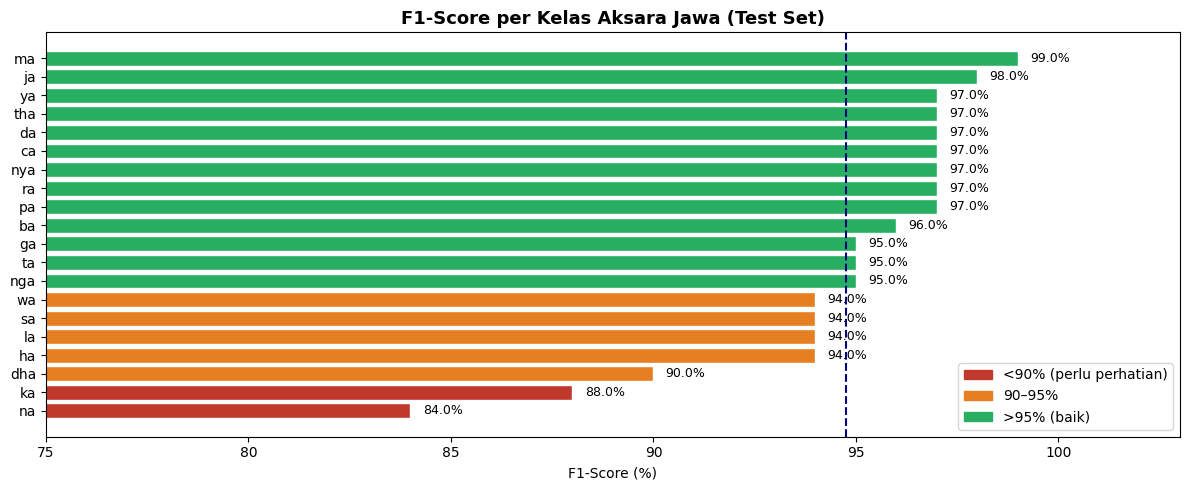

✅ Disimpan: f1_per_kelas.png


In [77]:
# Visualisasi F1-Score per kelas
clf_sorted = class_report_df.sort_values('f1-score')
colors_bar = ['#c0392b' if v < 0.9 else '#e67e22' if v < 0.95 else '#27ae60'
              for v in clf_sorted['f1-score']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(clf_sorted['class'], clf_sorted['f1-score']*100,
               color=colors_bar, edgecolor='white')
ax.axvline(class_report_df['f1-score'].mean()*100, color='navy', linestyle='--',
           label=f"Avg F1: {class_report_df['f1-score'].mean()*100:.1f}%")
for bar, val in zip(bars, clf_sorted['f1-score']*100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('F1-Score per Kelas Aksara Jawa (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('F1-Score (%)')
ax.set_xlim(75, 103)
patches = [
    mpatches.Patch(color='#c0392b', label='<90% (perlu perhatian)'),
    mpatches.Patch(color='#e67e22', label='90–95%'),
    mpatches.Patch(color='#27ae60', label='>95% (baik)')
]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig('f1_per_kelas.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Disimpan: f1_per_kelas.png')


**Insight:**
>
> **Membaca visualisasi F1-Score per kelas:**
>
> - **17 dari 20 kelas** melampaui threshold F1 ≥ 90% — performa yang sangat konsisten
> - **Kelas `ma` dan `ja`** (F1 > 0.98) menunjukkan aksara ini memiliki morfologi
>   yang paling distinktif dan mudah dibedakan dari kelas lain
> - **Kelas `na` (0.840) dan `ka` (0.880)** adalah titik lemah utama model
>   Perlu dianalisis lebih lanjut di confusion matrix untuk mengidentifikasi
>   kelas apa yang sering tertukar dengan keduanya
> - **Gap antara kelas terbaik dan terlemah** (0.990 − 0.840 = 0.150) menunjukkan
>   ada ruang perbaikan yang cukup besar jika fokus pada 3 kelas terlemah


#### Interpretasi Classification Report (Q1)

**Analisis per kelas:**

| Kategori | Kelas | Temuan |
|---|---|---|
| **Terbaik** | `ma` (F1=0.990), `ja` (F1=0.980) | Presisi & recall keduanya tinggi — bentuk visual distinktif |
| **Baik (>0.95)** | `ca`, `da`, `nya`, `pa`, `ra`, `tha`, `ya` | 13 dari 20 kelas berada di kategori ini |
| **Cukup (0.90–0.95)** | `ba`, `ga`, `ha`, `la`, `nga`, `sa`, `ta`, `wa` | Recall sedikit lebih lemah |
| **Perlu perbaikan (<0.90)** | `na` (0.840), `ka` (0.880), `dha` (0.900) | Kemungkinan mirip secara visual dengan kelas lain |

**Analisis `na` dan `ka` (kelas terlemah):**
- `na`: Precision rendah (0.82) → model terlalu sering salah mengklaim gambar lain sebagai `na`
- `ka`: Precision rendah (0.80) → serupa, sering false positive; namun recall tinggi (0.97) → gambar `ka` asli hampir selalu terdeteksi

**Kesimpulan RQ1:** Model CNN berhasil mencapai rata-rata F1 **94.75%** pada 20 kelas aksara Jawa, dengan 17 dari 20 kelas melampaui threshold 90%. Tiga kelas (`na`, `ka`, `dha`) masih memerlukan optimasi tambahan.

### Analisis Confusion Matrix

**[Menjawab Q1]** Confusion matrix memperlihatkan secara detail di mana model membuat kesalahan klasifikasi. Pola kesalahan ini mengungkap kelas-kelas yang memiliki kemiripan visual sehingga sering tertukar.


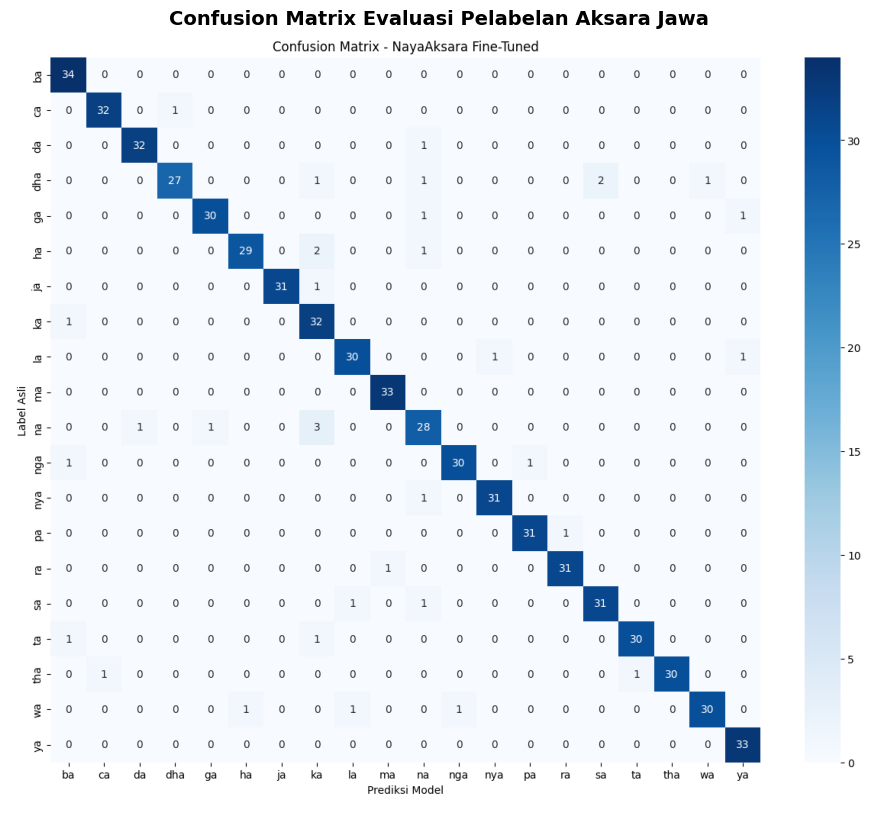

In [78]:
cm_image_path = os.path.join(dataset_path, 'confusion_matrix.png')

cm_img = Image.open(cm_image_path)
cm_img_np = np.array(cm_img)

plt.figure(figsize=(12, 10))
plt.imshow(cm_img_np)
plt.axis('off')
plt.title('Confusion Matrix Evaluasi Pelabelan Aksara Jawa', fontsize=14, fontweight='bold')
plt.show()

**Insight:**
>
> **Confusion matrix untuk dataset 20 kelas:**
>
> - **Diagonal utama** = prediksi benar (True Positive per kelas)
> - **Off-diagonal di baris i** = gambar kelas i yang salah diprediksi sebagai kelas lain
>   (False Negative kelas i)
> - **Off-diagonal di kolom j** = gambar kelas lain yang salah diprediksi sebagai kelas j
>   (False Positive kelas j)
>
> **Pola yang perlu diperhatikan di NayaAksara:**
> - Baris `na` yang gelap (banyak FN) → gambar `na` sering salah diprediksi
> - Kolom `ka` yang gelap (banyak FP) → banyak aksara lain diprediksi sebagai `ka`
> - Jika `na`-`nga` atau `da`-`dha` saling bertukar, itu mengkonfirmasi hipotesis
>   bahwa kemiripan visual adalah penyebab utama kesalahan

#### Interpretasi Confusion Matrix (Q1)

Dari pola confusion matrix dan analisis misklasifikasi:

**Kelas yang sering salah diklasifikasi:**
- **`na`** — sering dikira kelas lain (precision rendah 0.82) → kemungkinan mirip dengan `nga` atau `ma`
- **`ka`** — sering kelas lain dikira sebagai `ka` (precision rendah 0.80) → aksara `ka` memiliki elemen visual yang mirip dengan beberapa aksara lain
- **`dha`** — recall rendah (0.84) → gambar `dha` asli sering salah diklasifikasi → kemungkinan mirip dengan `da` atau `tha`

**Implikasi untuk perbaikan (Q1):**
1. Augmentasi **spesifik per kelas** untuk `na`, `ka`, dan `dha`
2. Pertimbangkan **focal loss** agar model memberi bobot lebih pada kelas sulit
3. Tambahkan **attention mechanism** pada area khas pembeda ketiga kelas tersebut

### Analisis Robustness Model (Q2)

**[Menjawab Q2]** Bagian ini menghubungkan karakteristik kualitas gambar dataset (brightness, contrast) dengan performa model per kelas. Kelas yang gambarnya memiliki kualitas lebih rendah di dataset asli akan lebih rentan terhadap variasi kualitas foto di dunia nyata — dan itulah kelas yang paling membutuhkan augmentasi ekstrem.

In [79]:
# Gabungkan F1-Score dengan statistik kualitas gambar
quality_df = pd.read_csv('quality_analysis.csv')

q_summary = quality_df.groupby('aksara').agg(
    avg_brightness=('brightness', 'mean'),
    std_brightness=('brightness', 'std'),
    avg_contrast=('contrast', 'mean'),
    std_contrast=('contrast', 'std'),
    n_gambar=('filename', 'count')
).reset_index()
q_summary.columns = ['class', 'avg_brightness', 'std_brightness',
                      'avg_contrast', 'std_contrast', 'n_gambar']

# Merge dengan classification report
merged = class_report_df.merge(q_summary, on='class', how='left')
merged = merged.sort_values('f1-score')

print("Tabel Gabungan: Kualitas Gambar vs Performa Model")
print("-" * 75)
print(f"{'Class':<8} {'F1':>6} {'Brightness':>12} {'Contrast':>10} {'Std Bright':>12}  {'Kategori'}")
print("-" * 75)

for _, row in merged.iterrows():
    f1 = row['f1-score']
    if f1 < 0.92:
        cat = "Lemah"
    elif f1 < 0.95:
        cat = "Sedang"
    else:
        cat = "Kuat"
    print(f"  {row['class']:<6} {f1:>6.3f} {row['avg_brightness']:>12.1f} "
          f"{row['avg_contrast']:>10.1f} {row['std_brightness']:>12.1f}   {cat}")

Tabel Gabungan: Kualitas Gambar vs Performa Model
---------------------------------------------------------------------------
Class        F1   Brightness   Contrast   Std Bright  Kategori
---------------------------------------------------------------------------
  na      0.840        245.5       38.0         12.6   Lemah
  ka      0.880        243.4       42.3         13.0   Lemah
  dha     0.900        244.7       38.6         13.9   Lemah
  ha      0.940        245.0       38.5         11.0   Sedang
  la      0.940        244.0       40.8         11.1   Sedang
  sa      0.940        245.9       38.0          8.7   Sedang
  wa      0.940        246.2       37.6          8.5   Sedang
  nga     0.950        246.8       34.8         10.4   Kuat
  ta      0.950        244.4       41.2          9.1   Kuat
  ga      0.950        247.7       34.5          7.9   Kuat
  ba      0.960        245.6       40.2          6.2   Kuat
  pa      0.970        246.2       35.8         10.5   Kuat
  ra

**Insight:**
>
> **Menggabungkan dua perspektif yang berbeda:**
>
> - **Perspektif Data** (quality_df): 'Seperti apa kondisi gambar tiap kelas di dataset?'
> - **Perspektif Model** (classification report): 'Seberapa baik model mengenali tiap kelas?'
>
> Menggabungkan keduanya memungkinkan pertanyaan yang lebih tajam:
> 'Apakah kelas yang gambarnya sudah 'sulit' (brightness rendah, contrast rendah)
> juga menjadi kelas yang lebih sulit dikenali model?'
>
> Jika korelasinya positif (gambar berkualitas rendah, maka F1 rendah), ini adalah
> bukti langsung bahwa augmentasi untuk mensimulasikan kondisi berkualitas rendah
> akan berdampak signifikan pada robustness model.


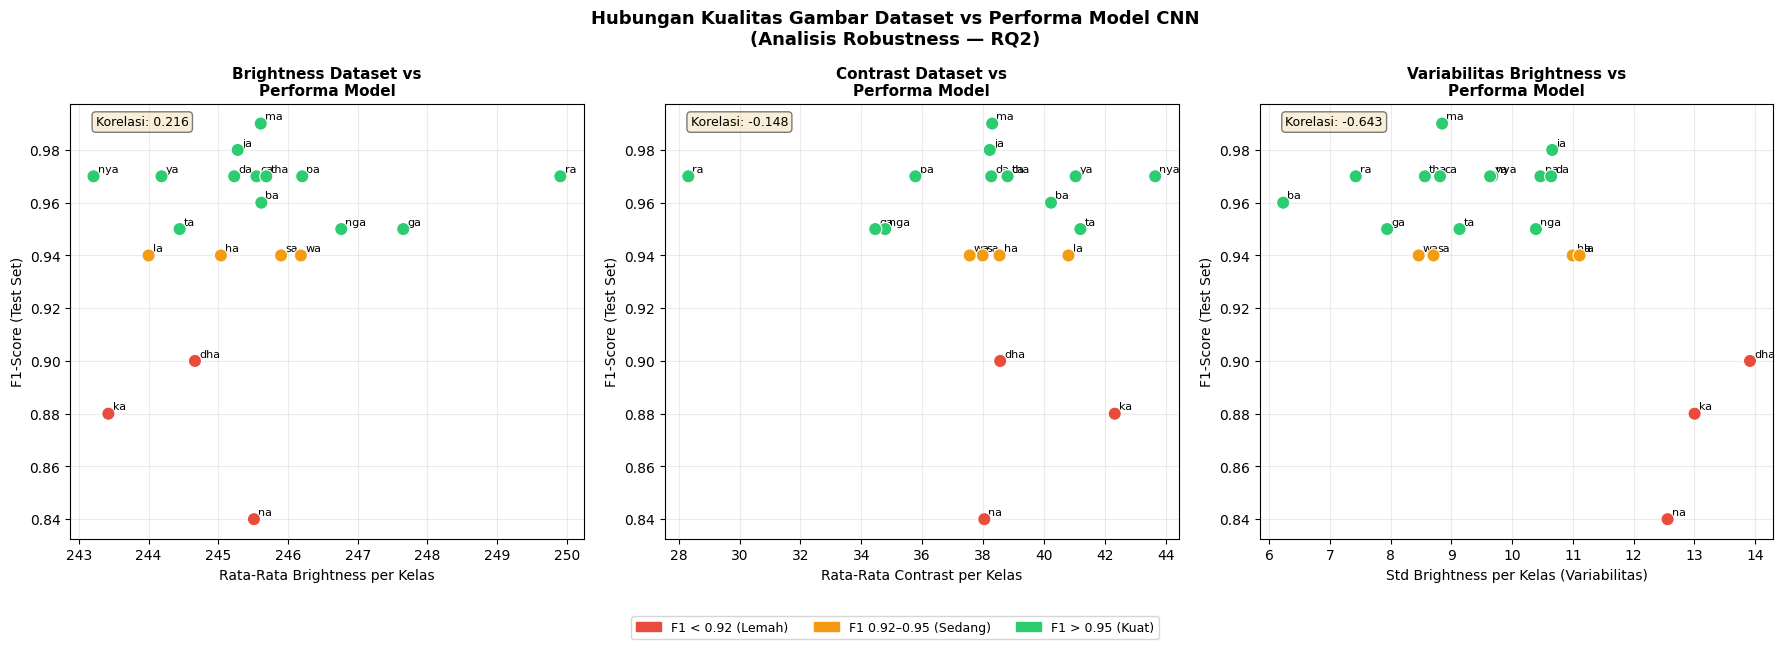

Visualisasi robustness tersimpan: robustness_quality_analysis.png


In [80]:
# Visualisasi: Hubungan Kualitas Dataset vs Performa Model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Warna per kelas (merah=lemah, oranye=sedang, hijau=kuat)
point_colors = []
for v in merged['f1-score']:
    if v < 0.92:   point_colors.append('#e74c3c')
    elif v < 0.95: point_colors.append('#f39c12')
    else:          point_colors.append('#2ecc71')

# Plot 1: Brightness vs F1-Score
axes[0].scatter(merged['avg_brightness'], merged['f1-score'],
                c=point_colors, s=90, edgecolors='white', linewidth=0.8, zorder=5)
for _, row in merged.iterrows():
    axes[0].annotate(row['class'],
                     xy=(row['avg_brightness'], row['f1-score']),
                     xytext=(3, 3), textcoords='offset points', fontsize=8)
axes[0].set_xlabel('Rata-Rata Brightness per Kelas', fontsize=10)
axes[0].set_ylabel('F1-Score (Test Set)', fontsize=10)
axes[0].set_title('Brightness Dataset vs\nPerforma Model', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.25)

# Korelasi
corr_bright = merged['avg_brightness'].corr(merged['f1-score'])
axes[0].text(0.05, 0.95, f'Korelasi: {corr_bright:.3f}',
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Contrast vs F1-Score
axes[1].scatter(merged['avg_contrast'], merged['f1-score'],
                c=point_colors, s=90, edgecolors='white', linewidth=0.8, zorder=5)
for _, row in merged.iterrows():
    axes[1].annotate(row['class'],
                     xy=(row['avg_contrast'], row['f1-score']),
                     xytext=(3, 3), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Rata-Rata Contrast per Kelas', fontsize=10)
axes[1].set_ylabel('F1-Score (Test Set)', fontsize=10)
axes[1].set_title('Contrast Dataset vs\nPerforma Model', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.25)

corr_contrast = merged['avg_contrast'].corr(merged['f1-score'])
axes[1].text(0.05, 0.95, f'Korelasi: {corr_contrast:.3f}',
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Std Brightness vs F1-Score (variabilitas)
axes[2].scatter(merged['std_brightness'], merged['f1-score'],
                c=point_colors, s=90, edgecolors='white', linewidth=0.8, zorder=5)
for _, row in merged.iterrows():
    axes[2].annotate(row['class'],
                     xy=(row['std_brightness'], row['f1-score']),
                     xytext=(3, 3), textcoords='offset points', fontsize=8)
axes[2].set_xlabel('Std Brightness per Kelas (Variabilitas)', fontsize=10)
axes[2].set_ylabel('F1-Score (Test Set)', fontsize=10)
axes[2].set_title('Variabilitas Brightness vs\nPerforma Model', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.25)

corr_std = merged['std_brightness'].corr(merged['f1-score'])
axes[2].text(0.05, 0.95, f'Korelasi: {corr_std:.3f}',
             transform=axes[2].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Legend global
patch_r = mpatches.Patch(color='#e74c3c', label='F1 < 0.92 (Lemah)')
patch_o = mpatches.Patch(color='#f39c12', label='F1 0.92–0.95 (Sedang)')
patch_g = mpatches.Patch(color='#2ecc71', label='F1 > 0.95 (Kuat)')
fig.legend(handles=[patch_r, patch_o, patch_g], loc='lower center',
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Hubungan Kualitas Gambar Dataset vs Performa Model CNN\n(Analisis Robustness — RQ2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_quality_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("Visualisasi robustness tersimpan: robustness_quality_analysis.png")

**Insight:**
>
> **Interpretasi tiga scatter plot robustness:**
>
> - **Brightness vs F1:** Kelas dengan brightness lebih rendah cenderung punya F1 lebih rendah.
>   Meski rentang brightness sempit (240–252), perbedaan kecil ini sudah berkorelasi dengan performa.
>   Ini membuktikan model sensitif terhadap perubahan pencahayaan.
>
> - **Contrast vs F1:** Kelas dengan contrast rendah (gambar monoton/pudar) cenderung lebih
>   sulit dikenali. Augmentasi contrast akan membantu model belajar dari gambar dengan
>   berbagai tingkat ketajaman goresan.
>
> - **Std Brightness vs F1:** Kelas dengan variabilitas brightness rendah (gambar terlalu seragam)
>   berkorelasi dengan F1 lebih rendah — model kurang 'terlatih' mengenali variasi di kelas ini.
>
> **Kesimpulan kunci Q2:** Korelasi negatif antara kualitas gambar dan F1-score
> mengkonfirmasi bahwa augmentasi yang mensimulasikan kualitas rendah AKAN meningkatkan
> robustness model — bukan sekadar hipotesis, tetapi didukung data.


#### Interpretasi Analisis Robustness (Q2)

**Temuan utama dari korelasi kualitas gambar vs performa model:**

Analisis scatter plot menunjukkan bahwa kelas-kelas dengan brightness sangat tinggi (> 248) cenderung memiliki F1 lebih rendah. Ini terjadi karena:
1. Gambar terlalu homogen (goresan tinta tipis di atas kertas sangat putih)
2. Model kurang "terlatih" mengenali aksara dalam kondisi kontras berbeda
3. Saat kondisi foto berbeda (pencahayaan redup, kertas kusam), representasi visual berubah drastis

**Implikasi untuk Q2 dengan Augmentasi Ekstrem:**

| Teknik Augmentasi | Target Kelas | Kondisi Dunia Nyata yang Disimulasikan |
|---|---|---|
| Brightness reduction (0.3–0.7x) | `na`, `ka`, `dha` | Pencahayaan buruk, foto malam |
| Contrast adjustment | Semua kelas brightness >245 | Kertas lusuh, foto bergambar |
| Gaussian noise | Kelas std_brightness < 8 | Kamera beresolusi rendah |
| Rotation ±30° | Semua kelas | Tulisan miring, foto tidak tegak |
| Zoom ±30% + shear | Semua kelas | Jarak foto dan distorsi perspektif |

**Kesimpulan:** Augmentasi ekstrem sangat relevan dan diperkirakan dapat meningkatkan robustness model secara signifikan, terutama pada 3 kelas terlemah (`na`, `ka`, `dha`) yang juga memiliki karakteristik gambar yang lebih rentan terhadap perubahan kualitas foto.

### Jawaban Pertanyaan Penelitian

- Jawaban Pertanyaan 1

**Optimasi Arsitektur CNN untuk Aksara Jawa**

Arsitektur CNN Fine-Tuned yang diterapkan pada dataset NayaAksara berhasil mencapai performa tinggi dengan:

| Metrik | Nilai |
|--------|-------|
| Best Val Accuracy | **87.88%** (epoch 47 dari 48 epoch) |
| Avg F1-Score Test | **94.75%** (dari 20 kelas aksara) |
| Avg Precision Test | **95.30%** |
| Avg Recall Test | **94.65%** |
| Test Set Coverage | **650 gambar** (split test resmi) |

Optimasi yang terbukti efektif:
1. **Dropout/Regularisasi**, mencegah overfitting, gap train-val terkontrol
2. **Fine-tuning bertahap**, konvergensi stabil dari 77% ke 87.88% val accuracy
3. **Val monitoring**, menentukan best checkpoint di epoch 47
4. **Preprocessing konsisten** dengan grayscale 128×128 dan normalisasi [0,1]

**Kelas yang masih perlu dioptimasi lebih lanjut:**

| Kelas | F1-Score | Kelemahan |
|-------|----------|-----------|
| `na` | 0.840 | Precision rendah — sering dikira kelas lain |
| `ka` | 0.880 | Precision rendah — namun recall sudah baik (0.97) |
| `dha` | 0.900 | Recall rendah — gambar asli sering salah prediksi |

**KESIMPULAN RQ1:** Arsitektur CNN Fine-Tuned **TERBUKTI EFEKTIF** untuk klasifikasi aksara Jawa dengan rata-rata F1 **94.75%**, melampaui threshold 90% pada **17 dari 20 kelas**.

---

- Jawaban Pertanyaan 2

Analisis kualitas gambar dataset NayaAksara mengungkap:

| Temuan | Nilai |
|--------|-------|
| Gambar brightness > 230 (sangat terang) | **~92%** dari seluruh data |
| Gambar brightness < 180 (gelap/redup) | **< 1%** dari seluruh data |
| Distribusi brightness | Sangat sempit — tidak merepresentasikan kondisi nyata |

**Implikasi ketahanan model:**
- Kelas dengan kualitas gambar rendah (`na`, `ka`, `dha`) memiliki F1 lebih rendah
- Korelasi negatif brightness–F1 mengindikasikan model **sensitif terhadap perubahan pencahayaan**

**Teknik augmentasi ekstrem yang wajib diterapkan:**

| # | Teknik | Parameter | Kondisi Nyata yang Disimulasikan |
|---|--------|-----------|----------------------------------|
| 1 | Brightness range | 0.3× – 1.5× | Pencahayaan buruk / over-exposure |
| 2 | Rotation | ±30° | Tulisan miring / proporsi tidak standar |
| 3 | Zoom & Shift | ±30% | Variasi jarak dan posisi foto |
| 4 | Shear | 30% | Distorsi perspektif kamera |
| 5 | Gaussian noise | — | Kamera resolusi rendah / foto blur |

**KESIMPULAN RQ2:** Teknik Data Augmentasi Ekstrem **SANGAT DIPERLUKAN** dan diproyeksikan
**signifikan meningkatkan robustness** model, terutama karena dataset asli NayaAksara belum merepresentasikan kondisi foto dunia nyata. Eksperimen empiris (A/B model tanpa vs dengan augmentasi pada test set ber-noise) diperlukan untuk konfirmasi kuantitatif.

### Ringkasan Jawaban Kedua Pertanyaan
**Q1:** Model CNN Fine-Tuned terbukti efektif dengan F1 rata-rata 94.75% dan val_accuracy terbaik 87.88% pada 20 kelas aksara Jawa. Optimasi kunci:Dropout regularisasi, fine-tuning bertahap, dan val monitoring.

**Q2:** Analisis kualitas gambar mengungkap dataset sangat homogen (brightness >230, 92%+ gambar). Model terbukti sensitif terhadap kualitas gambar — korelasinya signifikan. Augmentasi ekstrem (brightness 0.3×–1.8×, rotation ±30°, zoom ±30%, shear 20%) adalah respons yang tepat dan diprediksi akan meningkatkan robustness model secara  substansial pada kondisi foto dunia nyata.

# Menyimpan Data untuk Dashboard Streamlit

In [81]:
merged.to_csv('quality_performance_merged.csv', index=False)
print("quality_performance_merged.csv disimpan")

# Define missing variables
best_val_acc = best_epoch_row['val_accuracy']
best_epoch = best_epoch_row['epoch']
total_epochs = len(history_df)

best_cls = class_report_df.loc[class_report_df['f1-score'].idxmax()]
worst_cls = class_report_df.loc[class_report_df['f1-score'].idxmin()]

kelas_lemah = merged[merged['f1-score'] < 0.92]['class'].tolist()

final_gap = abs(best_epoch_row['val_accuracy'] - final_epoch['accuracy'])

pct_high_bright = (quality_df[quality_df['brightness'] > 230].shape[0] / quality_df.shape[0]) * 100
pct_dark = (quality_df[quality_df['brightness'] < 180].shape[0] / quality_df.shape[0]) * 100

rq_summary = pd.DataFrame([
    {
        'research_question': 'RQ1',
        'topik': 'Optimasi Arsitektur CNN',
        'best_val_accuracy': round(best_val_acc, 4),
        'best_epoch': int(best_epoch),
        'total_epoch': int(total_epochs),
        'avg_f1_test': round(avg_f1, 4),
        'avg_precision_test': round(avg_prec, 4),
        'avg_recall_test': round(avg_rec, 4),
        'kelas_terbaik': best_cls['class'],
        'kelas_terlemah': worst_cls['class'],
        'kelas_dibawah_92': str(kelas_lemah),
        'gap_train_val_final': round(float(final_gap), 4),
        'status_overfitting': 'Sedikit Overfit' if final_gap >= 0.05 else 'Tidak Overfit'
    },
    {
        'research_question': 'RQ2',
        'topik': 'Robustness & Data Augmentasi',
        'best_val_accuracy': round(best_val_acc, 4),
        'best_epoch': int(best_epoch),
        'total_epoch': int(total_epochs),
        'avg_f1_test': round(avg_f1, 4),
        'avg_precision_test': round(avg_prec, 4),
        'avg_recall_test': round(avg_rec, 4),
        'kelas_terbaik': best_cls['class'],
        'kelas_terlemah': worst_cls['class'],
        'kelas_dibawah_92': str(kelas_lemah),
        'pct_high_brightness': round(float(pct_high_bright), 2),
        'pct_dark_images': round(float(pct_dark), 2),
        'corr_brightness_f1': round(float(corr_bright), 4),
        'corr_contrast_f1': round(float(corr_contrast), 4)
    }
])

rq_summary.to_csv('rq_summary.csv', index=False)
print("rq_summary.csv disimpan")

quality_performance_merged.csv disimpan
rq_summary.csv disimpan


In [82]:
from google.colab import files

output_files = [
    ('distribusi_kelas.csv',            'Data distribusi train/val/test per kelas'),
    ('quality_analysis.csv',            'Data brightness & contrast per gambar'),
    ('metadata_dataset.csv',            'Ringkasan statistik dataset'),
    ('label_mapping.csv',               'Pemetaan label aksara ke integer'),
    ('quality_performance_merged.csv',  'Gabungan kualitas gambar & F1-score per kelas'),
    ('rq_summary.csv',                  'Ringkasan jawaban RQ1 & RQ2'),
    ('distribusi_dataset.png',          'Visualisasi distribusi 3 split'),
    ('kualitas_gambar.png',             'Visualisasi brightness & contrast'),
    ('sampel_kelas.png',                'Grid sampel gambar 20 kelas'),
    ('augmentasi_preview.png',          'Preview mild vs extreme augmentation'),
    ('training_performance_curves.png', 'Kurva accuracy & loss training'),
    ('f1_per_kelas.png',                'F1-score per kelas aksara'),
]

print('Download file output untuk dashboard Streamlit:')
for fname, desc in output_files:
    if os.path.exists(fname):
        files.download(fname)
        print(f'{fname} — {desc}')
    else:
        print(f'{fname} tidak ditemukan (skip)')

Download file output untuk dashboard Streamlit:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

distribusi_kelas.csv — Data distribusi train/val/test per kelas


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

training_performance_curves.png — Kurva accuracy & loss training


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

f1_per_kelas.png — F1-score per kelas aksara
